## Deep Learning, DL Models, and Applications

```python
# Task 4: Custom Gradient Descent Optimizers with Momentum,
# RMSprop, and Adam
# ● Objective: Master adaptive learning rate mechanics and temporal update optimization
# algorithms by implementing high-performance weight updates from scratch.
# ● Required Tech Stack: PyTorch (using only tensor mathematics, no torch.optim), NumPy.
# ● Task Description: Students will design a training harness utilizing PyTorch tensors. They
# must write optimizer update rules from scratch, calculating exponential moving averages of
# first and second raw moments, applying bias corrections, and tracking loss convergence
# rates on non-linear datasets
```

In [91]:
#Step 1: Import Libraries
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [92]:
#Step 2: Create Sample Data
X = torch.randn(100, 1)

Y = 2 * X + 3

In [93]:
#Step 3: Initialize Weights
W = torch.randn(1, requires_grad=False)

b = torch.randn(1, requires_grad=False)

In [94]:
#Step 4: Forward Function
def forward(X):
    return W * X + b

In [95]:
#Step 5: Loss Function (Mean Squared Error)
def loss_fn(pred, Y):
    return ((pred - Y) ** 2).mean()

In [96]:
#Step 6: Compute Gradients Manually
def gradients(X, Y, pred):

    dW = (2 * (pred - Y) * X).mean()

    db = (2 * (pred - Y)).mean()

    return dW, db

In [97]:
#Step 7: Gradient Descent
learning_rate = 0.1

def gradient_descent(W, b, dW, db):

    W = W - learning_rate * dW

    b = b - learning_rate * db

    return W, b

In [98]:
#Step 8: Momentum
vW = torch.zeros_like(W)

vB = torch.zeros_like(b)

beta = 0.9

In [99]:
def momentum(W, b, dW, db, vW, vB):

    vW = beta * vW + (1 - beta) * dW

    vB = beta * vB + (1 - beta) * db

    W = W - learning_rate * vW

    b = b - learning_rate * vB

    return W, b, vW, vB

In [100]:
#Step 9: RMSprop
sW = torch.zeros_like(W)

sB = torch.zeros_like(b)

epsilon = 1e-8

In [101]:
def rmsprop(W, b, dW, db, sW, sB):

    sW = 0.9 * sW + 0.1 * (dW ** 2)

    sB = 0.9 * sB + 0.1 * (db ** 2)

    W = W - learning_rate * dW / (torch.sqrt(sW) + epsilon)

    b = b - learning_rate * db / (torch.sqrt(sB) + epsilon)

    return W, b, sW, sB

In [102]:
#Step 10: Adam
mW = torch.zeros_like(W)

mB = torch.zeros_like(b)

vW = torch.zeros_like(W)

vB = torch.zeros_like(b)

In [103]:
def adam(W, b, dW, db, mW, mB, vW, vB, t):

    beta1 = 0.9
    beta2 = 0.999
    epsilon = 1e-8

    mW = beta1 * mW + (1 - beta1) * dW
    mB = beta1 * mB + (1 - beta1) * db

    vW = beta2 * vW + (1 - beta2) * (dW ** 2)
    vB = beta2 * vB + (1 - beta2) * (db ** 2)

    mW_hat = mW / (1 - beta1 ** t)
    mB_hat = mB / (1 - beta1 ** t)

    vW_hat = vW / (1 - beta2 ** t)
    vB_hat = vB / (1 - beta2 ** t)

    W = W - learning_rate * mW_hat / (torch.sqrt(vW_hat) + epsilon)
    b = b - learning_rate * mB_hat / (torch.sqrt(vB_hat) + epsilon)

    return W, b, mW, mB, vW, vB

In [104]:
#Step 11: Training Loop (Gradient Descent Example)
losses = []

epochs = 100

for epoch in range(epochs):

    pred = forward(X)

    loss = loss_fn(pred, Y)

    dW, db = gradients(X, Y, pred)

    W, b = gradient_descent(W, b, dW, db)

    losses.append(loss.item())


In [105]:
W, b = gradient_descent(W, b, dW, db)

In [106]:
W, b, vW, vB = momentum(W, b, dW, db, vW, vB)

In [107]:
W, b, sW, sB = rmsprop(W, b, dW, db, sW, sB)

In [108]:
W, b, mW, mB, vW, vB = adam(W, b, dW, db, mW, mB, vW, vB, epoch + 1)

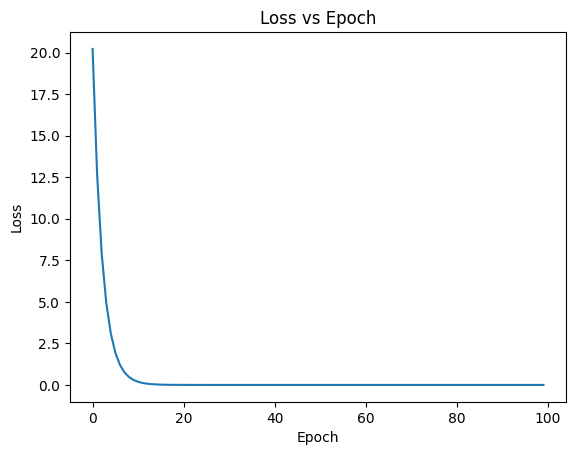

In [109]:
#Step 12: Plot the Loss
plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.show()